<table style="width:100%">
  <tr>
    <td valign="top"><img src="../data/img/FER_logo_2.png" width=300 height=80 align="left"></td>
    <td valign="top"><img src="../data/img/LARES_2_transparent.png" width=250 height=80 align="right"></td>
  </tr>
 </table>

# Cross-validation

![title](../data/img/cv_split.png)

## Import modules

In [1]:
import pandas as pd
import numpy as np

# fix random seed
np.random.seed(1)

In [2]:
from sklearn.metrics import root_mean_squared_error

In [3]:
#import warnings
#warnings.filterwarnings("ignore", category=FutureWarning)

## (Pre)process data

In [4]:
# import the data
X_train = pd.read_csv('../data/housing_prices/X_train.csv', index_col='Id')
y_train = pd.read_csv('../data/housing_prices/y_train.csv', index_col='Id')
X_test = pd.read_csv('../data/housing_prices/X_test.csv', index_col='Id')
y_test = pd.read_csv('../data/housing_prices/y_test.csv', index_col='Id')

In [5]:
# normalize the data
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [6]:
# merge data
X = pd.concat((X_train, X_test), axis=0)
y = pd.concat((y_train, y_test), axis=0)

## K-fold cross-validation
<img src="../data/img/Kfold_CV.png" alt="Kfold_CV" width="800"/> \
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html \
`sklearn.model_selection.`**`cross_val_score`**`(estimator, X, y=None, *, groups=None, scoring=None, cv=None, n_jobs=None, verbose=0, fit_params=None, params=None, pre_dispatch='2*n_jobs', error_score=nan)`

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html \
`sklearn.model_selection.`**`KFold`**`(n_splits=5, *, shuffle=False, random_state=None)`

Ridge info \
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html \
`sklearn.linear_model.`**`Ridge`**`(alpha=1.0, *, fit_intercept=True, copy_X=True, max_iter=None, tol=0.0001, solver='auto', positive=False, random_state=None)`

In [7]:
# additional imports
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold

Model performance with classical data splitting

In [8]:
# tune a simple Ridge estimator with default hyperparameter
estimator_classical = Ridge()
estimator_classical.fit(X_train, y_train)

# generate predictions
y_hat_classical = estimator_classical.predict(X_test)

# calculate and print RMSE
error = root_mean_squared_error(y_hat_classical, y_test)
print('RMSE = {:.6}'.format(error))

RMSE = 0.164313


Model performance with cross-validation

In [9]:
# which K to use?
print('Previous test set uses {:.4}% of data.'.format(X_test.shape[0]/X.shape[0]*100))

Previous test set uses 20.01% of data.


In [10]:
# define model with default hyperparameter
estimator_CV = Ridge()

# generate predictions using CV
cv = KFold(n_splits=5, shuffle=True, random_state=33)
errors = cross_val_score(estimator_CV, X, y, scoring='neg_root_mean_squared_error', cv=cv)

# print all errors including mean and std
print('RMSE with CV = ')
for e, f in zip(errors, range(1, 6)):
    print('Fold {}: {:.6}'.format(f, -e))
print('Mean  : {:.6}'.format(-np.array(errors).mean()))
print('Std   : {:.6}'.format(np.array(errors).std()))

RMSE with CV = 
Fold 1: 0.176318
Fold 2: 0.159961
Fold 3: 0.166445
Fold 4: 0.156701
Fold 5: 0.211816
Mean  : 0.174248
Std   : 0.0199426


## Grid Search cross-validation
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html \
`sklearn.model_selection.`**`GridSearchCV`**`(estimator, param_grid, *, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)` 

<img src="../data/img/CV_datasplit.png" alt="CV_datasplit" width="650"/>

In [11]:
# additional import
from sklearn.model_selection import GridSearchCV

In [12]:
# tune a simple Ridge estimator with default hyperparameter for reference
estimator_simple = Ridge()
estimator_simple.fit(X_train, y_train)

# generate predictions
y_hat_simple = estimator_simple.predict(X_test)

# calculate and print RMSE
error = root_mean_squared_error(y_hat_simple, y_test)
print('RMSE = {:6f}'.format(error))

RMSE = 0.164313


In [13]:
# grid search with cv on a Ridge estimator
estimator_cv = Ridge()
param_grid1 = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
gscv1 = GridSearchCV(estimator_cv, param_grid1, cv=5, scoring='neg_root_mean_squared_error', refit=True)
gscv1.fit(X_train, y_train)

# print the best hyperparameter
print('The best hyperparameter: {}'.format(gscv1.best_params_))

# print the best estimator
print('The best estimator: {}'.format(gscv1.best_estimator_))

The best hyperparameter: {'alpha': 10}
The best estimator: Ridge(alpha=10)


In [14]:
# what's the score?
y_hat_gscv1 = gscv1.best_estimator_.predict(X_test)
error = root_mean_squared_error(y_hat_gscv1, y_test)

print('RMSE = {:6f}'.format(error))

RMSE = 0.164024


**Can it be even better?**

In [15]:
# let's try out a different range for alpha
param_grid2 = {
    'alpha': [2, 5, 7, 10, 25, 50, 75]
}
gscv2 = GridSearchCV(estimator_cv, param_grid2, cv=5, scoring='neg_root_mean_squared_error', refit=True)
gscv2.fit(X_train, y_train)

# print the best hyperparameter
print('The best hyperparameter: {}'.format(gscv2.best_params_))

# print the best estimator
print('The best estimator: {}'.format(gscv2.best_estimator_))

The best hyperparameter: {'alpha': 25}
The best estimator: Ridge(alpha=25)


In [16]:
# what's the score?
y_hat_gscv2 = gscv2.best_estimator_.predict(X_test)
error = root_mean_squared_error(y_hat_gscv2, y_test)

print('RMSE = {:6f}'.format(error))

RMSE = 0.163653


**Question**   
Does it make sense to go further with hyperparameter search?  
What happened with test set?

In [17]:
cv = KFold(n_splits=5, shuffle=True, random_state=444)
gscv = GridSearchCV(estimator_cv, param_grid2, cv=cv, scoring='neg_root_mean_squared_error', refit=True)
gscv.fit(X_train, y_train)
print('The best hyperparameter: {}'.format(gscv.best_params_))

The best hyperparameter: {'alpha': 50}


## Nested cross validation

<img src="../data/img/nestedCV1.png" alt="nestedCV1" width="650"/>

### Nested CV v1  
Sklearn example with multiple nested CVs   
https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html

The best hyperparameter: {'alpha': 25}
The best hyperparameter: {'alpha': 25}
The best hyperparameter: {'alpha': 75}
The best hyperparameter: {'alpha': 50}
The best hyperparameter: {'alpha': 25}
The best hyperparameter: {'alpha': 50}
The best hyperparameter: {'alpha': 25}
The best hyperparameter: {'alpha': 50}
The best hyperparameter: {'alpha': 50}
The best hyperparameter: {'alpha': 25}
The best hyperparameter: {'alpha': 50}
The best hyperparameter: {'alpha': 25}
The best hyperparameter: {'alpha': 25}
The best hyperparameter: {'alpha': 10}
The best hyperparameter: {'alpha': 25}
The best hyperparameter: {'alpha': 50}
The best hyperparameter: {'alpha': 25}
The best hyperparameter: {'alpha': 25}
The best hyperparameter: {'alpha': 50}
The best hyperparameter: {'alpha': 10}
The best hyperparameter: {'alpha': 25}
The best hyperparameter: {'alpha': 75}
The best hyperparameter: {'alpha': 75}
The best hyperparameter: {'alpha': 50}
The best hyperparameter: {'alpha': 25}
The best hyperparameter: 

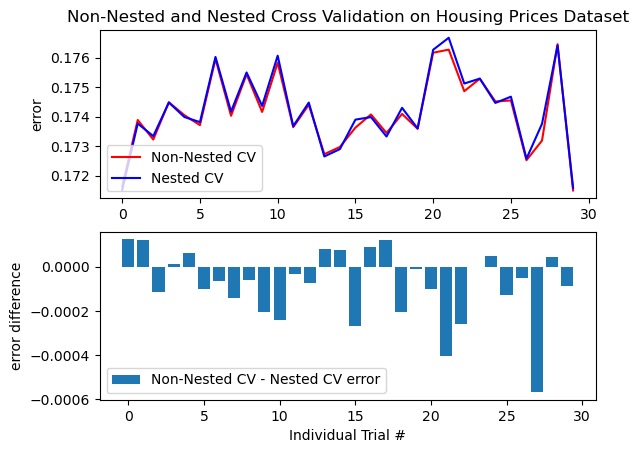

In [18]:
# import package for plotting and statistics
from matplotlib import pyplot as plt
from scipy import stats

# Number of random trials
NUM_TRIALS = 30

# Set estimator, parameter grid, scoring
estimator = Ridge()
p_grid = {'alpha': [2, 5, 7, 10, 25, 50, 75]}
scoring = 'neg_root_mean_squared_error'

# Arrays to store errors
non_nested_errors = np.zeros(NUM_TRIALS)
nested_errors = np.zeros(NUM_TRIALS)
best_alpha = np.zeros(NUM_TRIALS)

# Loop for each trial
for i in range(NUM_TRIALS):
    # Choose cross-validation techniques for the inner and outer loops, independently of the dataset.
    inner_cv = KFold(n_splits=4, shuffle=True, random_state=i)
    outer_cv = KFold(n_splits=4, shuffle=True, random_state=5*i)

    # Non_nested parameter search and scoring
    gscv_basic = GridSearchCV(estimator, p_grid, cv=outer_cv, scoring=scoring, n_jobs=-1)
    gscv_basic.fit(X, y)
    non_nested_errors[i] = -gscv_basic.best_score_
    best_alpha[i] = gscv_basic.best_params_['alpha']
    print('The best hyperparameter: {}'.format(gscv_basic.best_params_))

    # Nested CV with parameter optimization
    gscv_nested = GridSearchCV(estimator, p_grid, cv=inner_cv, n_jobs=-1)
    nested_score = cross_val_score(gscv_nested, X, y, cv=outer_cv, scoring=scoring, n_jobs=-1)
    nested_errors[i] = -nested_score.mean()
    
# mean of best alphas
print(' ')
print('Mean best alpha = {}'.format(best_alpha.mean()))
print('Mode best alpha = {}'.format(stats.mode(best_alpha).mode))

# scoring
error_difference = non_nested_errors - nested_errors
print(' ')
print("Average error difference of {:6f} with std. dev. of {:6f}.".format(
    error_difference.mean(), error_difference.std()
))

# Plot scores on each trial for nested and non-nested CV
plt.figure()
plt.subplot(211)
(non_nested_scores_line,) = plt.plot(non_nested_errors, color="r")
(nested_line,) = plt.plot(nested_errors, color="b")
plt.ylabel("error")
plt.legend(["Non-Nested CV", "Nested CV"])
plt.title("Non-Nested and Nested Cross Validation on Housing Prices Dataset")

# Plot bar chart of the difference.
plt.subplot(212)
difference_plot = plt.bar(range(NUM_TRIALS), error_difference)
plt.xlabel("Individual Trial #")
plt.legend(["Non-Nested CV - Nested CV error"])
plt.ylabel("error difference")

plt.show()

### Nested CV v2

<img src="../data/img/nestedCV2.png" alt="nestedCV2" width="650"/>

In [19]:
# define folds for hyperparameter search ("inner") and for validation of model accuracy ("outer")
cv_inner = KFold(n_splits=5, shuffle=True, random_state=5)
cv_outer = KFold(n_splits=5, shuffle=True, random_state=55)

In [20]:
# "inner" CV
param_grid = {
    'alpha': [1, 2, 5, 7, 10, 25, 50, 75, 100]
}
gscv = GridSearchCV(estimator_cv, param_grid, cv=cv_inner, scoring='neg_root_mean_squared_error')
gscv.fit(X, y)
best_alpha = gscv.best_params_['alpha']

print('Best alpha = {}'.format(best_alpha))
print('Inner RMSE = {:6f}'.format(-gscv.best_score_))

Best alpha = 50
Inner RMSE = 0.171630


In [21]:
# "outter" CV
estimator_ocv = Ridge(best_alpha)
scores = cross_val_score(estimator_ocv, X, y, scoring='neg_root_mean_squared_error', cv=cv_outer)

# print scores
print('Fold  RMSE')
for score, i in zip(scores, range(5)):
    print('   {}: {:6f}'.format(i, -score))
print('Mean: {:6f}'.format(-scores.mean()))
print(' Std: {:6f}'.format(scores.std()))

Fold  RMSE
   0: 0.213617
   1: 0.164630
   2: 0.170271
   3: 0.153261
   4: 0.167151
Mean: 0.173786
 Std: 0.020727


**Checking distributions of each fold**

In [22]:
# auxiliary function to plot PDF of equivalent normal distribution
from scipy import stats
def add_fit_to_histplot(a, fit=stats.norm, ax=None):

    if ax is None:
        ax = plt.gca()

    # compute bandwidth
    bw = len(a)**(-1/5) * a.std(ddof=1)
    # initialize PDF support
    x = np.linspace(a.min()-bw*3, a.max()+bw*3, 200)
    # compute PDF parameters
    params = fit.fit(a)
    # compute PDF values
    y = fit.pdf(x, *params)
    # plot the fitted continuous distribution
    ax.plot(x, y, color='#282828')
    return ax

Fold 0


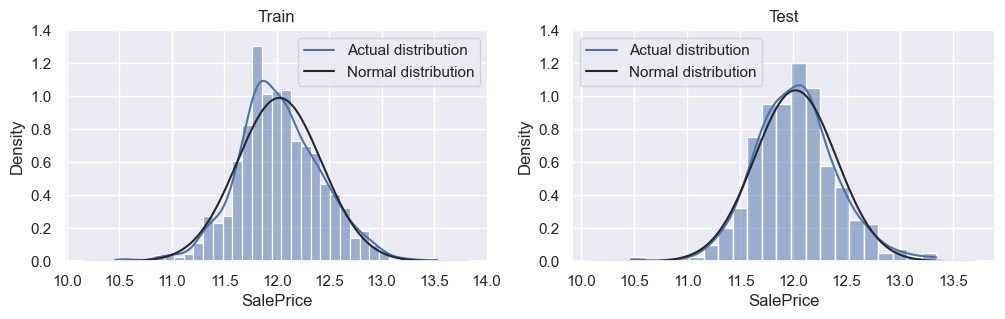

Fold 1


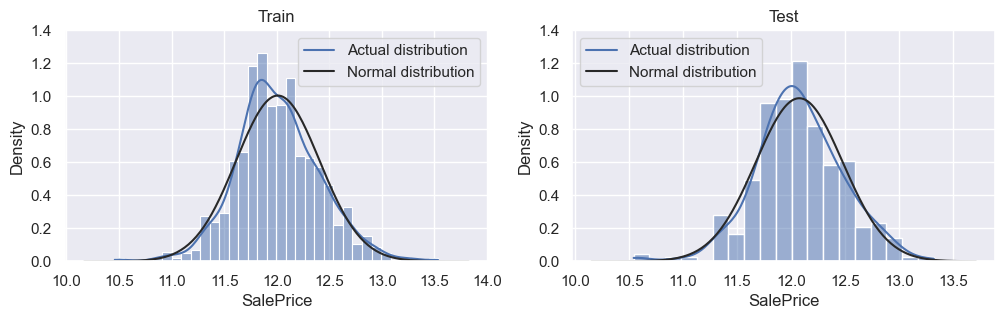

Fold 2


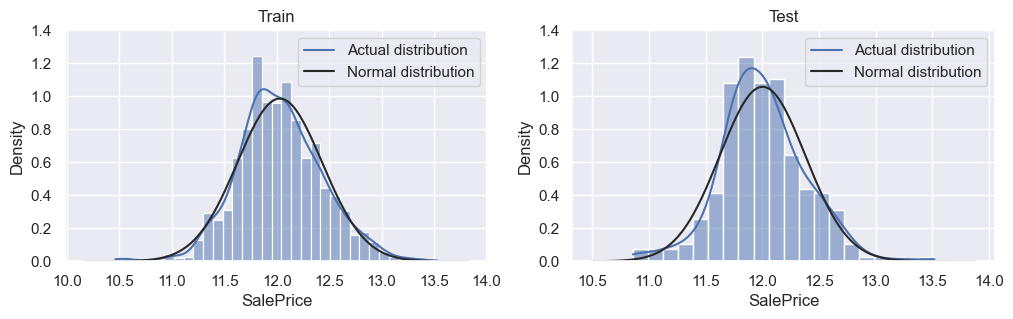

Fold 3


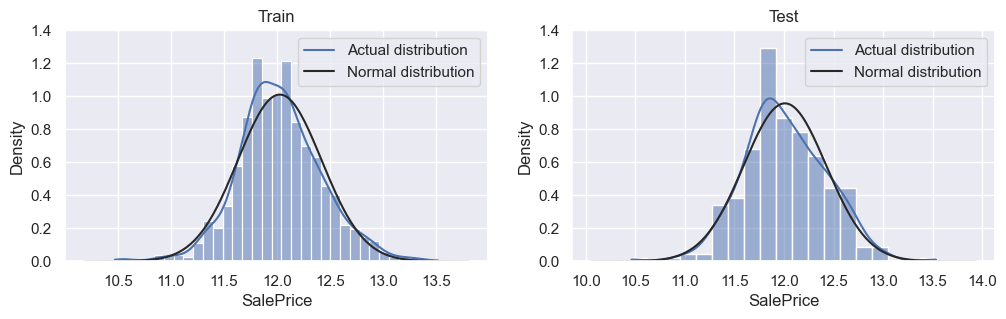

Fold 4


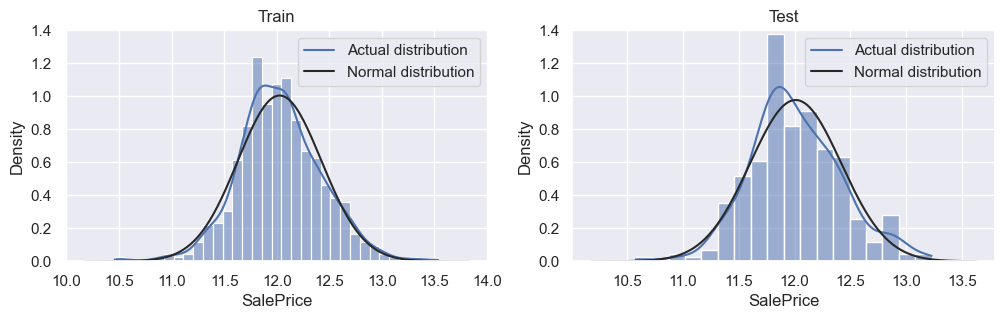

In [23]:
import seaborn as sns
sns.set_theme()

df = pd.concat((X,y), axis=1)
for (train, test), i in zip(cv_outer.split(X, y), range(5)):
    print('Fold {}'.format(i))
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=[12, 3])
    
    #ax1 = sns.distplot(df.iloc[train].SalePrice, fit=stats.norm, ax=ax1)
    ax1 = sns.histplot(df.iloc[train].SalePrice, stat='density', kde=True, ax=ax1)
    ax1 = add_fit_to_histplot(df.iloc[train].SalePrice, fit=stats.norm, ax=ax1)
    
    ax1.set_title('Train')
    ax1.set_ylim((0, 1.4))
    ax1.legend(['Actual distribution', 'Normal distribution'])
    
    #ax2 = sns.distplot(df.iloc[test].SalePrice, fit=stats.norm, ax=ax2)
    ax2 = sns.histplot(df.iloc[test].SalePrice, stat='density', kde=True, ax=ax2)
    ax2 = add_fit_to_histplot(df.iloc[test].SalePrice, fit=stats.norm, ax=ax2)
    ax2.legend(['Actual distribution', 'Normal distribution'])
    
    ax2.set_title('Test')
    ax2.set_ylim((0, 1.4))
    plt.show()

**Question**   
Can we compare it to the the first scenario (non-nested CV)?

In [24]:
# predict and calculate error
y_hat_ncv = gscv.best_estimator_.predict(X_test)
error = root_mean_squared_error(y_hat_ncv, y_test)

print('RMSE = {:6f}'.format(error))

RMSE = 0.161431


_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - basic_  
_Notebook: 5_Cross-Validation_  
_Instructors: [Filip Rukavina](mailto:filip.rukavina@fer.hr)_  
_Intended user: XY_  
_Date: 1st January 1991_  

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [filip.rukavina@fer.hr](mailto:filip.rukavina@fer.hr)_